# Change root directory

In [1]:
import os
root_dir = os.path.dirname(os.path.abspath(''))
os.chdir(root_dir)
print(f"Directory changed to: {os.getcwd()}")

Directory changed to: /home/bespi123/git/helmholtzCoilsDesigner


In [2]:
import time
import numpy as np
import pandas as pd
from src import helmCoils_simulator as sim
from src import plotMagneticField as hplot
from src import helmCoils_optmizer as opt
import matplotlib.pyplot as plt
import plotly.graph_objs as go

# Optimization to achieve a work space of 30cm

In [3]:
number_of_spires = 2
size_length =  0.72
distance_among_spires = 0.46
turns = [30, 30]
current = 1 
rotation_matrix = np.eye(3)
X_coil = sim.CoilParameters(number_of_spires, size_length, distance_among_spires, turns, current, rotation_matrix)

# Simulation settings
parallel_coils = 150
batch_Size = 120
grid_length_size = 0.01 #Space among evaluation points
num_seg = 100           #Numer of segments 

In [4]:
##Spawn spires
spires_x_sq = X_coil.square_spires(num_seg)

In [5]:
f0 = None
f0 = hplot.plot_spires(f0, spires_x_sq, color='black', row=None, col=None)

# Plot the square spires
f0.show()

In [6]:
X, Y, Z = sim.generate_range([-0.5, 0.5], [-0.5, 0.5], [-0.5, 0.5], step_size_x = grid_length_size)

hplot.plot_grid(X, Y, Z, f0)

In [ ]:
optimizer = opt.HelmholtzOptimizer(
    desired_size = 0.30,          # 30e-2 is 0.30 m
    coil = X_coil,
    fun = X_coil.square_spires,
    #fun = X_coil.circular_spires,
    fix_L=False,
    fixed_L_value=2.0,          # Set a fixed value for L if needed
    grid_length_size=grid_length_size,
    population = 20,
    generations = 100,
    mutation = 0.8,
    penalty = 5000,
    initial_values=[1.05, 0.59]
)
result = optimizer.optimize()

In [22]:
# Make sure that Ax, X, Y, Z, and test_3 functions are properly defined in your environment.
optimizer = opt.Source_optimizer(
    desired_magField = 70500e-9,          # T
    coil = X_coil,
    spires = spires_x_sq,
    fixed_V_limit = 12,
    max_N = 1000,
    max_I = 10,
    population = 1000,
    generations = 3000,
    mutation = 0.8,
    initial_values=[30, 1.5]
)
result = optimizer.optimize()

Slope of B_x vs I: 1.5220752304869168e-06 T/A
gen	nevals	min    	avg   
0  	999   	53.9483	8105.3
1  	921   	44.2735	6432.65
2  	896   	32.2704	5508.46
3  	892   	32.2704	4773.41
4  	887   	31.5185	3980.79
5  	912   	30.4889	2756.26
6  	913   	28.6752	1299.88
7  	905   	28.6752	702.911
8  	891   	28.6752	718.327
9  	911   	26.4962	848.436
10 	899   	26.4962	936.255
11 	887   	26.4962	899.866
12 	907   	26.4962	998.324
13 	902   	26.4962	892.762
14 	902   	26.9309	981.539
15 	903   	27.0278	1061.16
16 	890   	27.0278	1071.36
17 	899   	26.065 	1331.4 
18 	905   	26.065 	1536.49
19 	885   	26.065 	1376.85
20 	911   	26.065 	1150.59
21 	882   	26.065 	1109.89
22 	914   	26.065 	1069.45
23 	904   	26.065 	1264.15
24 	901   	26.065 	1308.79
25 	906   	26.065 	1493.69
26 	918   	26.065 	1418.53
27 	879   	26.065 	1468.35
28 	903   	26.065 	1308.19
29 	898   	26.065 	1323.18
30 	900   	26.065 	1323.24
31 	913   	26.065 	1648.61
32 	904   	26.065 	1438.48
33 	915   	26.065 	1513.52
34 	910   	

# Simulate Results

In [24]:
## Update obtained parameters to the models
X_coil.update_parameters(length=1.05 ,distance=0.59, turns=20, current=2.32)
##Spawn spires
spires_x_sq = X_coil.square_spires(num_seg)
f1 = None
f1 = hplot.plot_spires(f1, spires_x_sq, color='black', row=None, col=None)

# Plot the square spires
f1.show()

In [18]:
# Grid generation for simulation
X, Y, Z = sim.generate_range([-0.6, 0.6],[-0.6, 0.6], [-0.6, 0.6], step_size_x = grid_length_size)

hplot.plot_grid(X, Y, Z, f0)

In [19]:
#Run simulations
start_time = time.time() #Count start time
x_coil_results_s = sim.coil_simulation_parallel(X, Y, Z, X_coil, spires_x_sq, batch_Size, enable_progress_bar=True, n=parallel_coils)

end_time = time.time()   #Mark ending time

# Calcular la norma del campo magnético B = sqrt(Bx^2 + By^2 + Bz^2)
x_coil_results_s["B_norm"] = np.sqrt(x_coil_results_s["Bx"]**2 + x_coil_results_s["By"]**2 + x_coil_results_s["Bz"]**2)

#Calculate and show the simulation time
execution_time = end_time - start_time
print(f'Simulation finished in {execution_time/60} minutes...')

# Save results in a CSV file
output_file = 'data/triaxial_coil_results_square.csv'
x_coil_results_s.to_csv(output_file, index=False)

Simulation Progress: 100%|██████████| 376/376 [00:39<00:00,  9.41it/s]


Simulation finished in 0.6669743776321411 minutes...


In [ ]:
# Read data from previous simulations
x_coil_results_s = pd.read_csv('data/triaxial_coil_results_square.csv')

reference_value:  7.062429069459302e-05


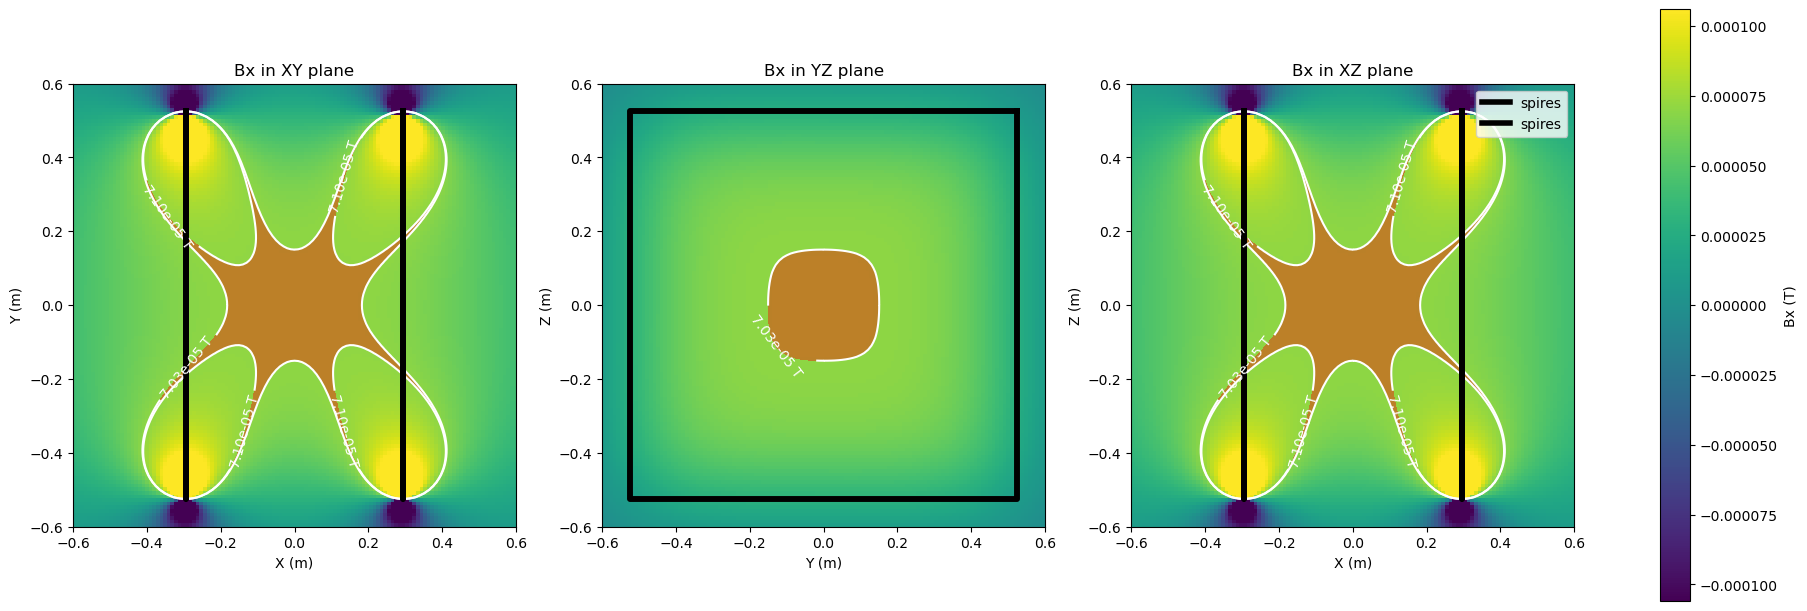

In [20]:
# Print the Bx component
hplot.plot_2d_magnetic_field(x_coil_results_s, spires_x_sq, index='Bx', use_fixed_zaxis=True)

In [25]:
hplot.simple_3d_surface_plot(x_coil_results_s, spires_x_sq, 'Bx', False)

reference_value:  7.062429069459302e-05


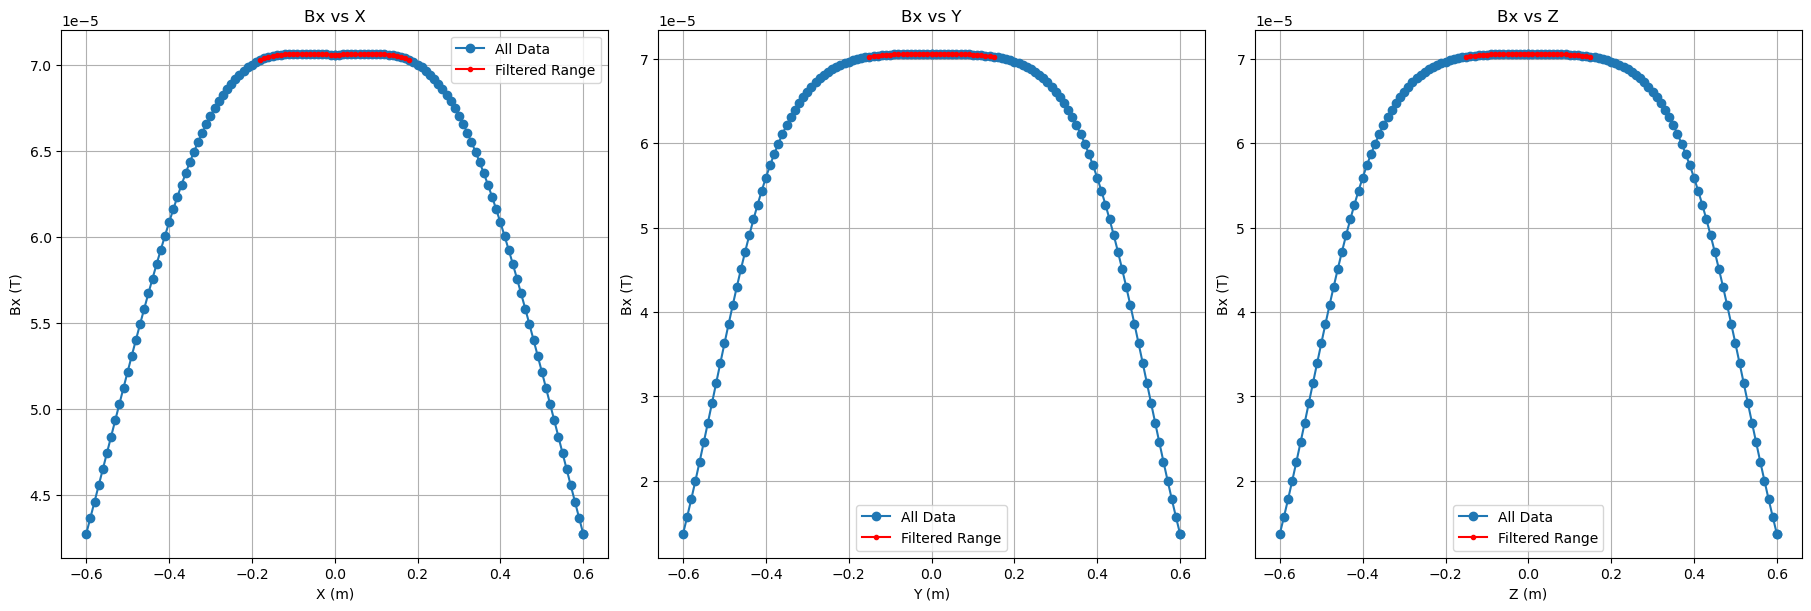

In [26]:
hplot.plot_mainAxis_field(x_coil_results_s, index='Bx')

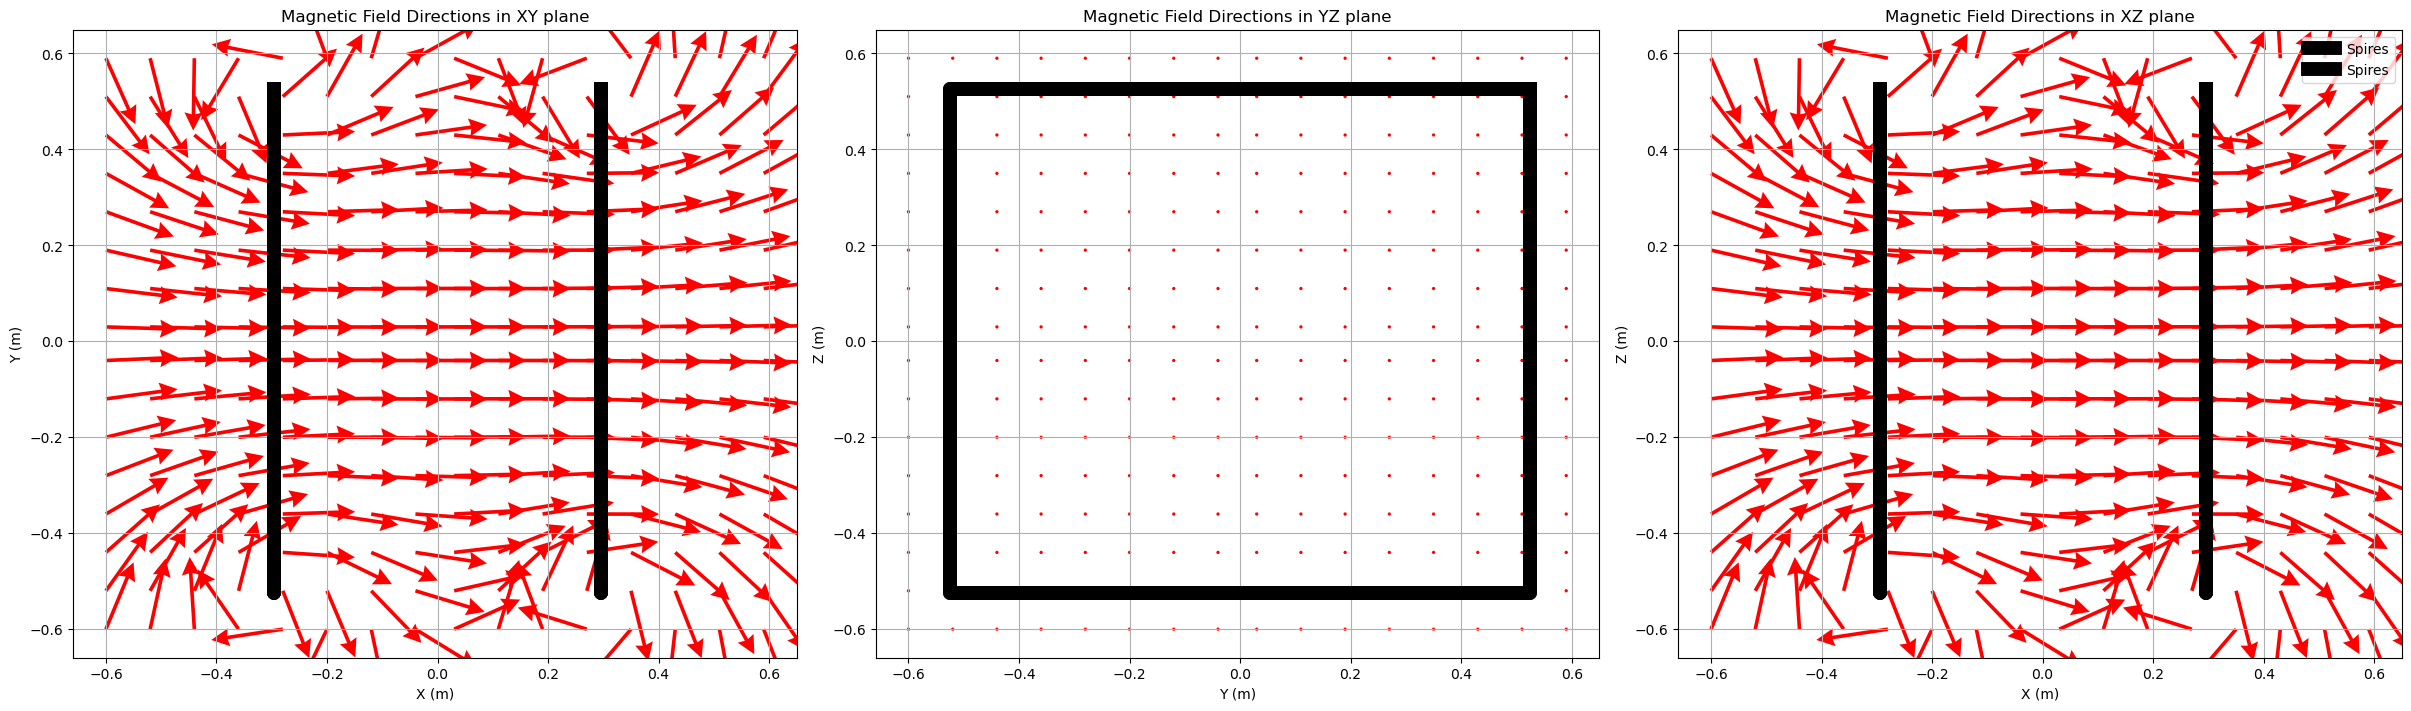

In [27]:
hplot.plot_magnetic_field_directions(x_coil_results_s, spires_x_sq)